In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("Heart Attack.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1319, 9)


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [6]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB

Missing Values:
age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
class            0
dtype: int64

Column Names:
['age', 'gender', 'impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin', 'class']

First 5 R

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [7]:
print("Target Classes:")
print(df["class"].value_counts())

Target Classes:
class
positive    810
negative    509
Name: count, dtype: int64


In [8]:
# Convert target labels:
# negative = 0
# positive = 1

df["class"] = df["class"].map({
    "negative": 0,
    "positive": 1
})

print(df["class"].value_counts())

df.head()

class
1    810
0    509
Name: count, dtype: int64


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0


In [9]:
X = df.drop("class", axis=1)
y = df["class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Features Shape: (1319, 8)
Target Shape: (1319,)

Features:
['age', 'gender', 'impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 1055
Testing Samples: 264


In [11]:
base_model = DecisionTreeClassifier(random_state=42)

bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train, y_train)

bagging_pred = bagging_model.predict(X_test)

print("Bagging training completed.")

Bagging training completed.


In [12]:
boosting_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

boosting_model.fit(X_train, y_train)

boosting_pred = boosting_model.predict(X_test)

print("Boosting training completed.")

Boosting training completed.


In [13]:
print("BAGGING CLASSIFIER")
print("-------------------")

print("Accuracy :", accuracy_score(y_test, bagging_pred))
print("Precision:", precision_score(y_test, bagging_pred))
print("Recall   :", recall_score(y_test, bagging_pred))
print("F1 Score :", f1_score(y_test, bagging_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        bagging_pred,
        target_names=["Negative", "Positive"]
    )
)

BAGGING CLASSIFIER
-------------------
Accuracy : 0.9848484848484849
Precision: 0.9876543209876543
Recall   : 0.9876543209876543
F1 Score : 0.9876543209876543

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98       102
    Positive       0.99      0.99      0.99       162

    accuracy                           0.98       264
   macro avg       0.98      0.98      0.98       264
weighted avg       0.98      0.98      0.98       264



In [14]:
print("BOOSTING CLASSIFIER")
print("-------------------")

print("Accuracy :", accuracy_score(y_test, boosting_pred))
print("Precision:", precision_score(y_test, boosting_pred))
print("Recall   :", recall_score(y_test, boosting_pred))
print("F1 Score :", f1_score(y_test, boosting_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        boosting_pred,
        target_names=["Negative", "Positive"]
    )
)

BOOSTING CLASSIFIER
-------------------
Accuracy : 0.9810606060606061
Precision: 0.9875776397515528
Recall   : 0.9814814814814815
F1 Score : 0.9845201238390093

Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.98      0.98       102
    Positive       0.99      0.98      0.98       162

    accuracy                           0.98       264
   macro avg       0.98      0.98      0.98       264
weighted avg       0.98      0.98      0.98       264



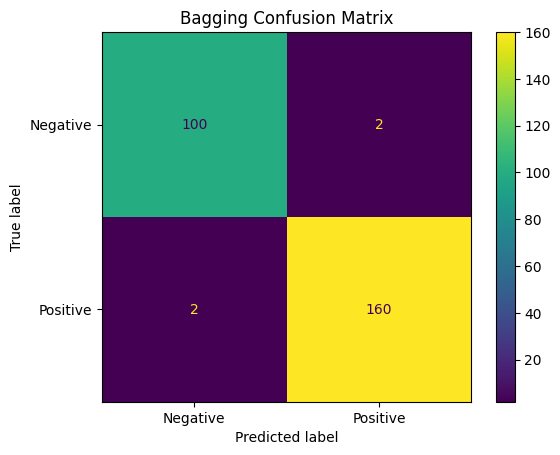

In [15]:
cm_bagging = confusion_matrix(y_test, bagging_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bagging,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Bagging Confusion Matrix")
plt.show()

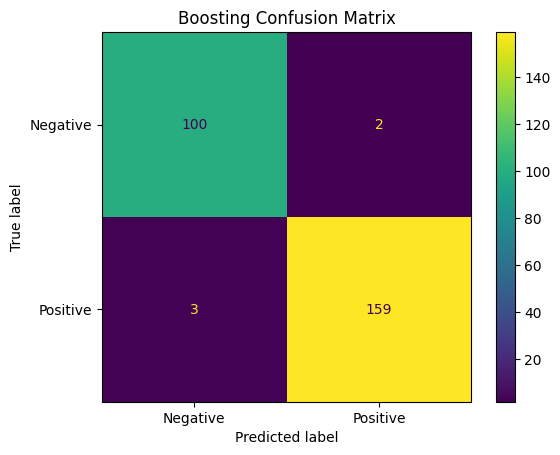

In [16]:
cm_boosting = confusion_matrix(y_test, boosting_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_boosting,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Boosting Confusion Matrix")
plt.show()

In [17]:
results = pd.DataFrame({
    "Model": ["Bagging", "Boosting"],

    "Accuracy": [
        accuracy_score(y_test, bagging_pred),
        accuracy_score(y_test, boosting_pred)
    ],

    "Precision": [
        precision_score(y_test, bagging_pred),
        precision_score(y_test, boosting_pred)
    ],

    "Recall": [
        recall_score(y_test, bagging_pred),
        recall_score(y_test, boosting_pred)
    ],

    "F1 Score": [
        f1_score(y_test, bagging_pred),
        f1_score(y_test, boosting_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Bagging,0.984848,0.987654,0.987654,0.987654
1,Boosting,0.981061,0.987578,0.981481,0.984520


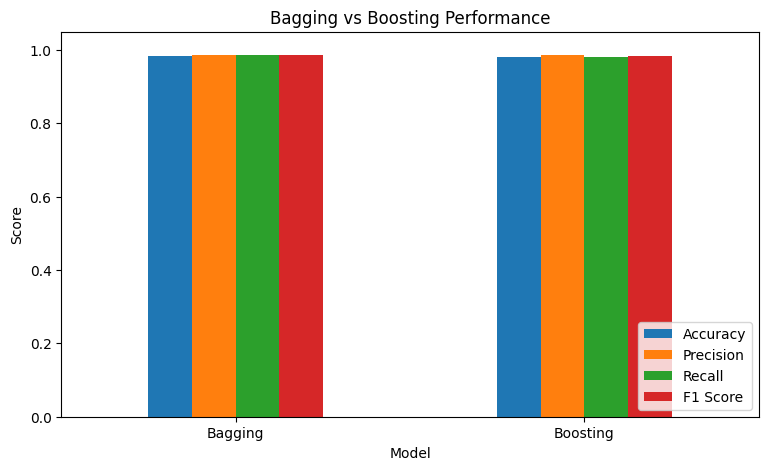

In [18]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Bagging vs Boosting Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

In [19]:
print("MODEL PERFORMANCE COMPARISON")
print("============================")

print(results.to_string(index=False))

print("\nBest Model for Each Metric")
print("--------------------------")

for metric in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    best_index = results[metric].idxmax()

    print(
        f"{metric}: "
        f"{results.loc[best_index, 'Model']} "
        f"({results.loc[best_index, metric]:.4f})"
    )

MODEL PERFORMANCE COMPARISON
   Model  Accuracy  Precision   Recall  F1 Score
 Bagging  0.984848   0.987654 0.987654  0.987654
Boosting  0.981061   0.987578 0.981481  0.984520

Best Model for Each Metric
--------------------------
Accuracy: Bagging (0.9848)
Precision: Bagging (0.9877)
Recall: Bagging (0.9877)
F1 Score: Bagging (0.9877)
